In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import geopandas as gpd

In [2]:
from src.config import RAW_DATA
from src.config import FIGURES_DIR

In [3]:
df = pd.read_csv(RAW_DATA, sep = ';')
df.head()

,code_commune,nom_commune,region,departement,population,strate_population,commune_rurale,commune_montagne,commune_touristique,tranche_revenu_habitant,recettes_fonctionnement_par_hab,depenses_fonctionnement_par_hab,frais_personnel_par_hab,depenses_equipement_par_hab,epargne_brute_par_hab,encours_dette_par_hab,dotation_etat_par_hab,impots_locaux_par_hab
0,75056,Paris,Île-de-France,Paris,2182174,10,Non,Non,Non,5,3458.07,3236.98,1198.21,572.59,221.10,4269.03,0.02,1039.39
1,13055,Marseille,Provence-Alpes-Côte d'Azur,Bouches-du-Rhône,877095,10,Non,Non,Oui,2,1509.93,1233.87,750.66,173.96,276.06,1736.44,266.10,957.54
2,69123,Lyon,Auvergne-Rhône-Alpes,Rhône,529570,10,Non,Non,Oui,3,1376.48,1177.39,694.91,159.80,199.09,686.15,127.82,856.10
3,31555,Toulouse,Occitanie,Haute-Garonne,498596,10,Non,Non,Oui,2,1280.81,1146.35,700.28,255.67,134.47,474.53,148.55,784.99
4,06088,Nice,Provence-Alpes-Côte d'Azur,Alpes-Maritimes,345528,10,Non,Non,Oui,2,1676.30,1571.70,910.29,206.69,104.60,1521.06,205.70,960.22


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34932 entries, 0 to 34931
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   code_commune                     34932 non-null  str    
 1   nom_commune                      34932 non-null  str    
 2   region                           34932 non-null  str    
 3   departement                      34932 non-null  str    
 4   population                       34932 non-null  int64  
 5   strate_population                34932 non-null  int64  
 6   commune_rurale                   34932 non-null  str    
 7   commune_montagne                 34932 non-null  str    
 8   commune_touristique              34932 non-null  str    
 9   tranche_revenu_habitant          34932 non-null  int64  
 10  recettes_fonctionnement_par_hab  34926 non-null  float64
 11  depenses_fonctionnement_par_hab  34926 non-null  float64
 12  frais_personnel_par_hab      

Notre jeu de donnés contient 34 932 communes !

On commence par afficher le type de chaque colonne afin de repérer des anomalies, afin de voir si une conversion de type est nécessaire (par exemple l'age stocké en `string`)  .

In [5]:
df.dtypes

code_commune                           str
nom_commune                            str
region                                 str
departement                            str
population                           int64
strate_population                    int64
commune_rurale                         str
commune_montagne                       str
commune_touristique                    str
tranche_revenu_habitant              int64
recettes_fonctionnement_par_hab    float64
depenses_fonctionnement_par_hab    float64
frais_personnel_par_hab            float64
depenses_equipement_par_hab        float64
epargne_brute_par_hab              float64
encours_dette_par_hab              float64
dotation_etat_par_hab              float64
impots_locaux_par_hab              float64
dtype: object

Avant de lancer la moindre analyse, il est important de vérifier la fiabilité de nos données. Cette étape d'exploration permet de nous assurer que nos analyses sont basées sur des données propres et d'éviter les conclusions biaisées.

# Gestion des doublons

On s'assure qu'il n'y a pas de doublons au niveau des communes qui pourraient biaiser nos statistiques :

In [6]:
doublons = df[df.duplicated(subset=['code_commune'])]
doublons

,code_commune,nom_commune,region,departement,population,strate_population,commune_rurale,commune_montagne,commune_touristique,tranche_revenu_habitant,recettes_fonctionnement_par_hab,depenses_fonctionnement_par_hab,frais_personnel_par_hab,depenses_equipement_par_hab,epargne_brute_par_hab,encours_dette_par_hab,dotation_etat_par_hab,impots_locaux_par_hab


# Gestions des valeurs manquantes 

In [7]:
df.isna().mean()

code_commune                       0.000000
nom_commune                        0.000000
region                             0.000000
departement                        0.000000
population                         0.000000
strate_population                  0.000000
commune_rurale                     0.000000
commune_montagne                   0.000000
commune_touristique                0.000000
tranche_revenu_habitant            0.000000
recettes_fonctionnement_par_hab    0.000172
depenses_fonctionnement_par_hab    0.000172
frais_personnel_par_hab            0.000172
depenses_equipement_par_hab        0.000172
epargne_brute_par_hab              0.000172
encours_dette_par_hab              0.000172
dotation_etat_par_hab              0.014972
impots_locaux_par_hab              0.000286
dtype: float64

On observe qu'il y'a des valeurs manquantes. Avant de supprimer ou compléter quoi que ce soit, on commence par investiguer la cause de ces données manquantes pour comprendre d'où vient le problème.

In [8]:
df.loc[df['recettes_fonctionnement_par_hab'].isna()]

,code_commune,nom_commune,region,departement,population,strate_population,commune_rurale,commune_montagne,commune_touristique,tranche_revenu_habitant,recettes_fonctionnement_par_hab,depenses_fonctionnement_par_hab,frais_personnel_par_hab,depenses_equipement_par_hab,epargne_brute_par_hab,encours_dette_par_hab,dotation_etat_par_hab,impots_locaux_par_hab
34926,55039,Beaumont-en-Verdunois,Grand Est,Meuse,0,0,Oui,Non,Non,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34927,55307,Louvemont-Côte-du-Poivre,Grand Est,Meuse,0,0,Oui,Non,Non,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34928,55050,Bezonvaux,Grand Est,Meuse,0,0,Oui,Non,Non,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34929,55139,Cumières-le-Mort-Homme,Grand Est,Meuse,0,0,Oui,Non,Non,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34930,55239,Haumont-près-Samogneux,Grand Est,Meuse,0,0,Oui,Non,Non,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34931,55189,Fleury-devant-Douaumont,Grand Est,Meuse,0,0,Oui,Non,Non,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### La liste des 6 communes identifiées :
* Beaumont-en-Verdunois (Meuse)
* Louvemont-Côte-du-Poivre (Meuse)
* Bezonvaux (Meuse)
* Cumières-le-Mort-Homme (Meuse)
* Haumont-près-Samogneux (Meuse)
* Fleury-devant-Douaumont (Meuse)

Ce sont les "villages morts pour la France", entièrement détruits en 1916 durant la bataille de Verdun. Le sol, truffé de munitions non explosées et de restes humains, a été classé en "zone rouge" et interdit de reconstruction. 

Pour préserver leur mémoire, la France a choisi de maintenir leur existence juridique. Chacune de ces communes possède encore aujourd'hui un maire désigné par le préfet et un conseil municipal, mais **aucun habitant et aucun budget courant**.

On continue d'essayer de comprendre pourquoi il manque des valeurs dans la colonne `impots`

In [9]:
df.loc[df['impots_locaux_par_hab'].isna(), 'nom_commune'].value_counts()

nom_commune
Castelnau-Magnoac           1
Île-Molène                  1
Palneca                     1
Lopigna                     1
Beaumont-en-Verdunois       1
Louvemont-Côte-du-Poivre    1
Bezonvaux                   1
Cumières-le-Mort-Homme      1
Haumont-près-Samogneux      1
Fleury-devant-Douaumont     1
Name: count, dtype: int64

Pour les quelques autres communes (hors villages morts pour la France) qui affichent un montant d'impôts locaux à zéro, après quelques recherches, ce n'est pas une incohérence dans les données, mais des cas de figure bien réels : on peut les regrouper en trois catégories :

* **La Corse (Palneca, Lopigna) :** En raison du statut fiscal dérogatoire historique de l'île  et d'une base fiscale très faible dans l'intérieur rural, certaines micro-communes ne perçoivent quasiment rien en impôts locaux classiques. 

* **Les îles d'exception (Île-Molène) :** C'est un privilège historique d'exemption totale. Pour inciter les gens à rester sur ces îles isolées et rudes, il n'y a tout simplement pas de taxe foncière. La commune tourne exclusivement grâce aux subventions publiques.

* **Le transfert fiscal à l'intercommunalité (Castelnau-Magnoac) :** Ici, c'est purement comptable. La commune a transféré la gestion et la perception de sa fiscalité à sa communauté de communes. L'argent lui revient ensuite sous forme de compensation, ce qui fait basculer la ligne budgétaire des "Impôts locaux" vers les "Recettes globales de fonctionnement".

In [10]:
villes_sans_dotation = df[df['dotation_etat_par_hab'].isna()][['nom_commune', 'departement', 'tranche_revenu_habitant']]
print(villes_sans_dotation.head(20))

              nom_commune           departement  tranche_revenu_habitant
29   Boulogne-Billancourt        Hauts-de-Seine                        5
56             Courbevoie        Hauts-de-Seine                        4
75    Issy-les-Moulineaux        Hauts-de-Seine                        4
79       Levallois-Perret        Hauts-de-Seine                        5
94      Neuilly-sur-Seine        Hauts-de-Seine                        5
346               Blagnac         Haute-Garonne                        2
391   Vélizy-Villacoublay              Yvelines                        3
465             Carquefou      Loire-Atlantique                        3
474               Mougins       Alpes-Maritimes                        4
529                Meylan                 Isère                        4
606          Saint-Égrève                 Isère                        2
617           Blanquefort               Gironde                        2
624           Fos-sur-Mer      Bouches-du-Rhône    

Il reste encore 523 communes avec des valeurs manquantes sur la colonne `dotation_etat_par_hab`. Remplacer ces `NaN` par la moyenne nationale serait une erreur : ces lignes vides sont le résultat direct de la politique de redistribution de l'État. 

Si l'État estime qu'une commune est suffisamment riche pour s'autofinancer, il coupe purement et simplement sa dotation. On retrouve dans ces 523 communes trois profils bien distincts :

* **Profil 1 : Les villes Bourgeoises (Tranche 5) :** C'est le cas le plus intuitif. Des villes comme Neuilly-sur-Seine ou Levallois-Perret concentrent des habitants très aisés et des bases fiscales très élevées. L'État leur retire la dotation au nom de la solidarité nationale.

* **Profil 2 : Les communes Industrielles (Tranches 1 à 4) :** C'est l'insight le plus contre-intuitif du jeu de données : de nombreuses communes de ce groupe n'ont pas d'habitants riches, mais abritent par exemple **une centrale nucléaire, un barrage hydroélectrique, un aéroport ou une immense zone commerciale**. Ces infrastructures génèrent des millions d'euros d'impôts économiques pour la mairie. L'État coupe donc la dotation de la mairie, même si ses habitants sont des ouvriers ou des employés.

* **Profil 3 : Les Communes Nouvelles (Fusions) :** Une partie de ces valeurs manquantes correspond aux communes ayant fusionné récemment. Durant leur période de transition légale, leur dotation est gelée ou versée sous un autre régime comptable, créant un trou temporaire dans la colonne.

Ainsi, on remplace leur valeur par un zéro !

In [11]:
df['dotation_etat_par_hab'] = df['dotation_etat_par_hab'].fillna(0)

communes_zero_impot = ['Castelnau-Magnoac', 'Île-Molène', 'Palneca', 'Lopigna']
df.loc[df['nom_commune'].isin(communes_zero_impot), 'impots_locaux_par_hab'] = 0

Avant de commencer notre étude approfondie sur chaque variable, on commence par catégoriser les variables numériques et catégorielles : 

In [12]:
numerical_features = df.select_dtypes(exclude = 'str').columns.to_list()
categorical_features = [col for col in df.columns if col not in numerical_features]

In [13]:
print(f"Features numériques : ({len(numerical_features)} au total)\n", numerical_features)
print("\n")
print(f"Features catégorielles : ({len(categorical_features)} au total)\n", categorical_features)

Features numériques : (11 au total)
 ['population', 'strate_population', 'tranche_revenu_habitant', 'recettes_fonctionnement_par_hab', 'depenses_fonctionnement_par_hab', 'frais_personnel_par_hab', 'depenses_equipement_par_hab', 'epargne_brute_par_hab', 'encours_dette_par_hab', 'dotation_etat_par_hab', 'impots_locaux_par_hab']


Features catégorielles : (7 au total)
 ['code_commune', 'nom_commune', 'region', 'departement', 'commune_rurale', 'commune_montagne', 'commune_touristique']


# Analyse Univariée 

- ## Features catégorielles 

In [14]:
mask_high_card_cols = df[categorical_features].nunique() > 10

high_card_cols = mask_high_card_cols[mask_high_card_cols].index.to_list()
low_card_cols =[col for col in categorical_features if col not in high_card_cols]

print(f"Features à haute cardinalité : \n{high_card_cols}")
print("\n")
print(f"Features à basse cardinalité : \n{low_card_cols}")
print("\n")
print(f"Nombres de labels par feature à basse cardinalité :\n{df[low_card_cols].nunique()}")


Features à haute cardinalité : 
['code_commune', 'nom_commune', 'region', 'departement']


Features à basse cardinalité : 
['commune_rurale', 'commune_montagne', 'commune_touristique']


Nombres de labels par feature à basse cardinalité :
commune_rurale         2
commune_montagne       2
commune_touristique    2
dtype: int64


C:\Users\imad\AppData\Local\Temp\ipykernel_6220\4216081631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df[col], stat='percent', palette = "Set2")


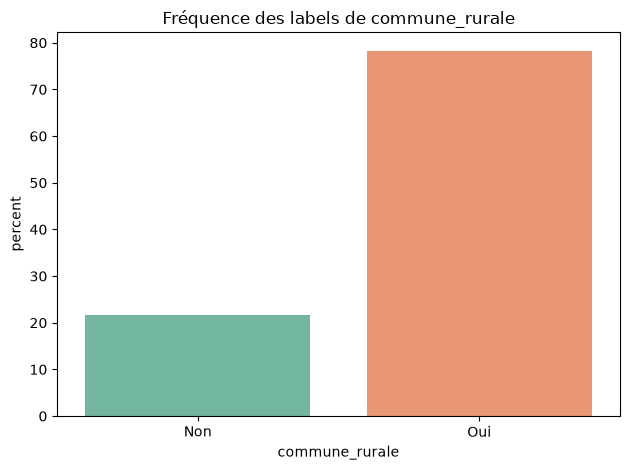

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\4216081631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df[col], stat='percent', palette = "Set2")


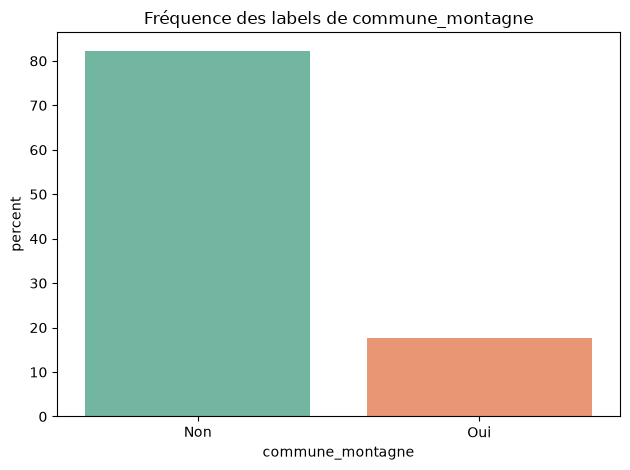

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\4216081631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df[col], stat='percent', palette = "Set2")


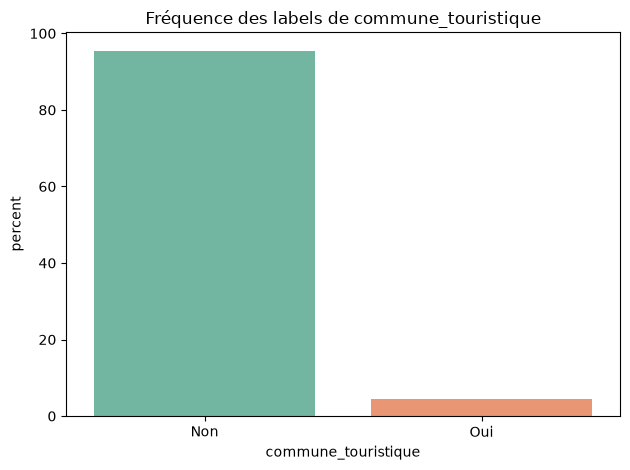

In [15]:
for col in low_card_cols:
    sns.countplot(x = df[col], stat='percent', palette = "Set2")
    plt.title(f"Fréquence des labels de {col}")
    plt.tight_layout()
    nom_fichier = f"countplot_{col}.png"
    path_countplot = FIGURES_DIR / nom_fichier
    
    plt.savefig(path_countplot, dpi=300, bbox_inches='tight', transparent=False)
    plt.show()

- ## Features numériques  

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


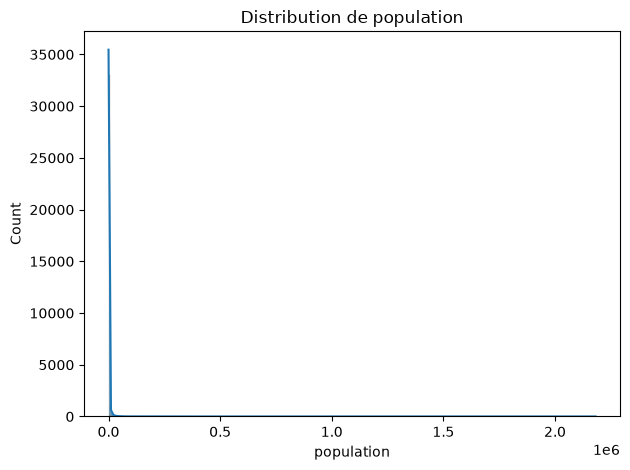

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


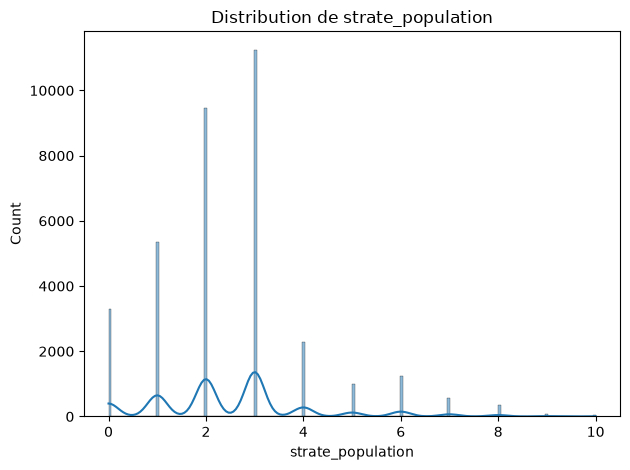

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


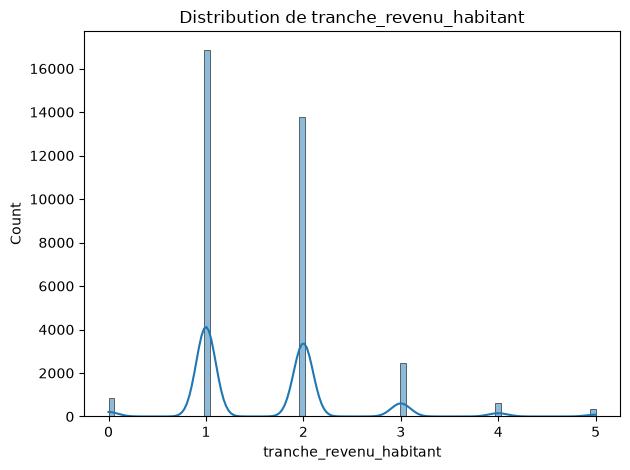

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


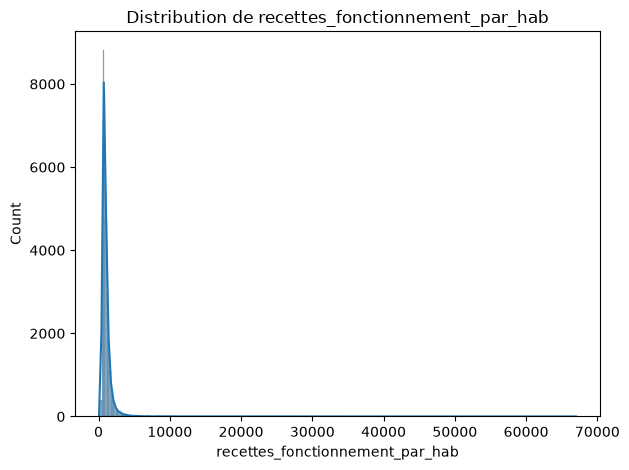

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


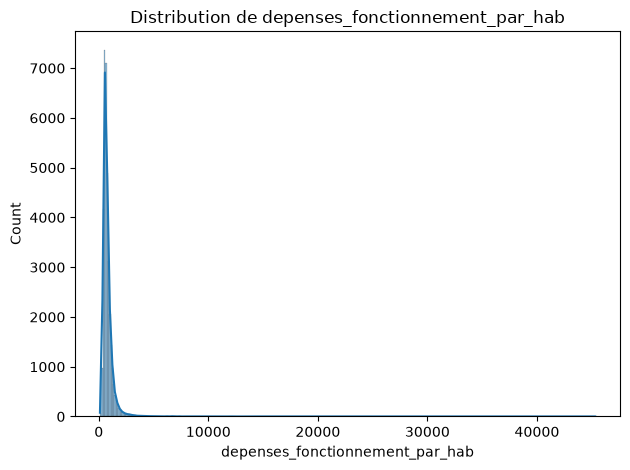

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


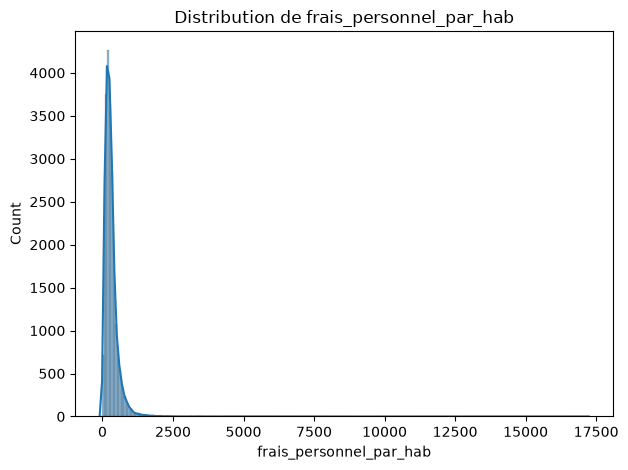

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


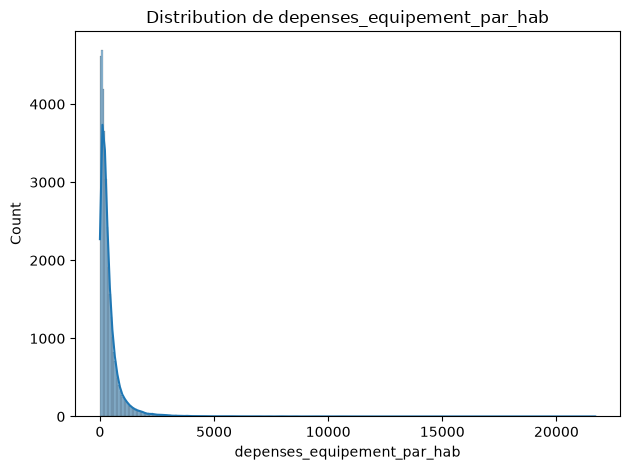

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


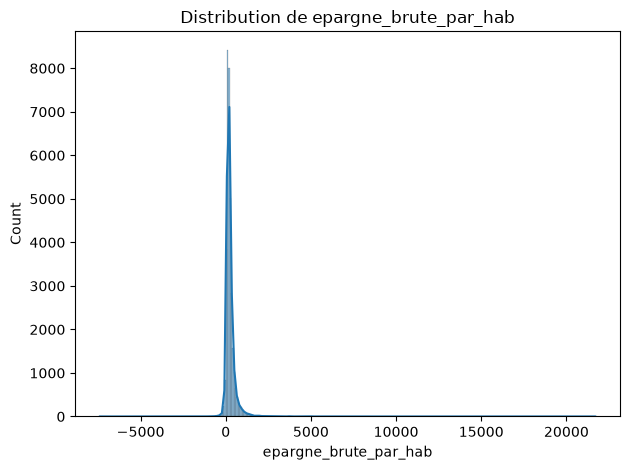

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


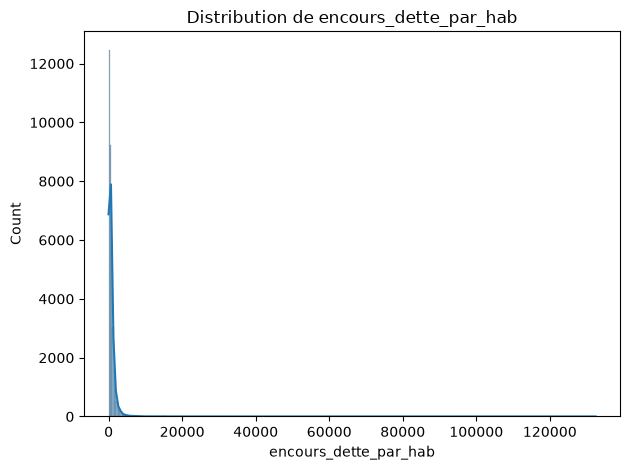

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


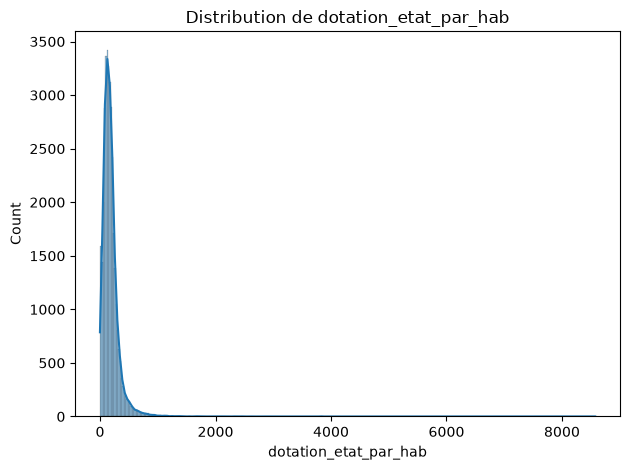

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\37583730.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x = df[col], palette="Set2", kde = True)


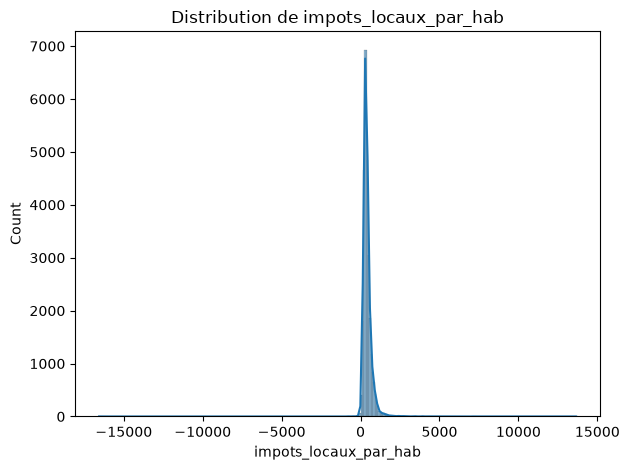

In [16]:
for col in numerical_features:
    sns.histplot(x = df[col], palette="Set2", kde = True)
    plt.title(f"Distribution de {col}")
    plt.tight_layout()
    nom_fichier = f"histplot__{col}.png"
    path_histplot = FIGURES_DIR / nom_fichier
    
    plt.savefig(path_histplot, dpi=300, bbox_inches='tight', transparent=False)
    plt.show()

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


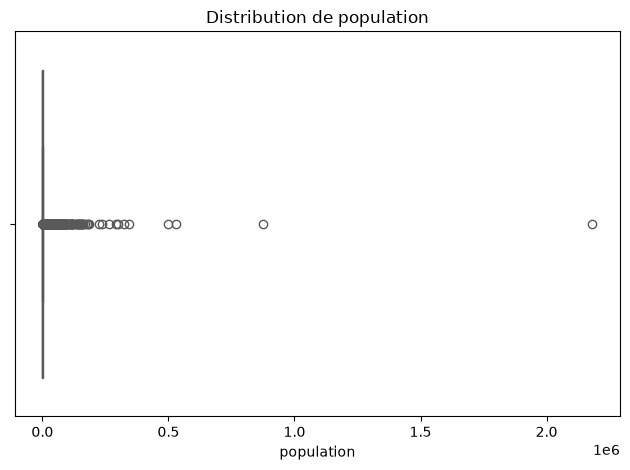

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


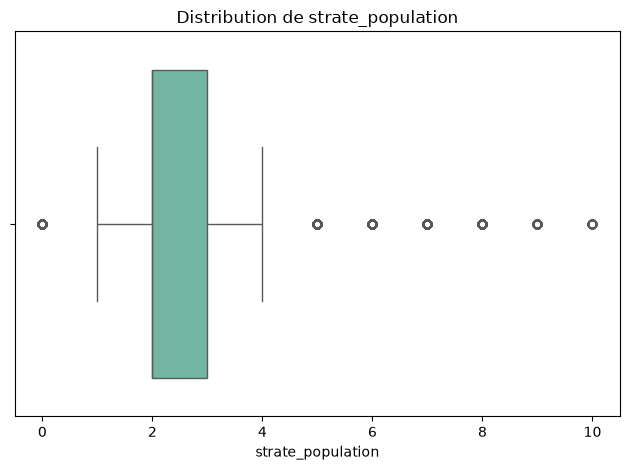

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


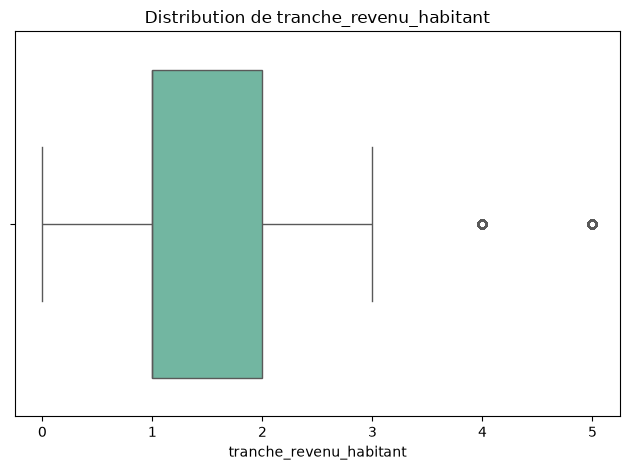

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


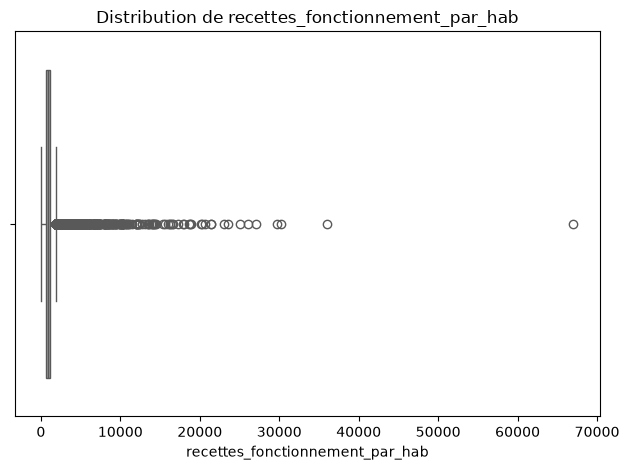

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


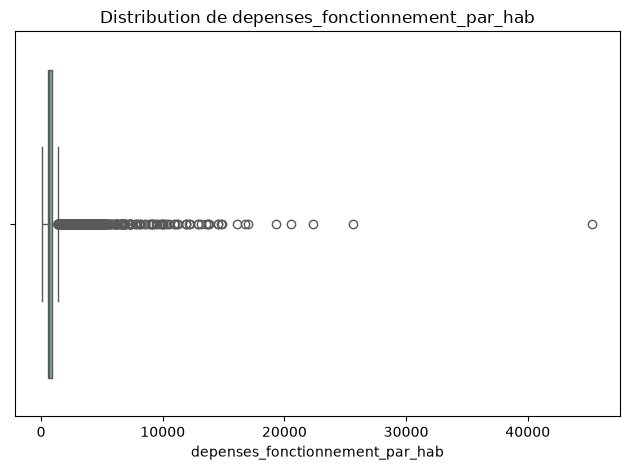

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


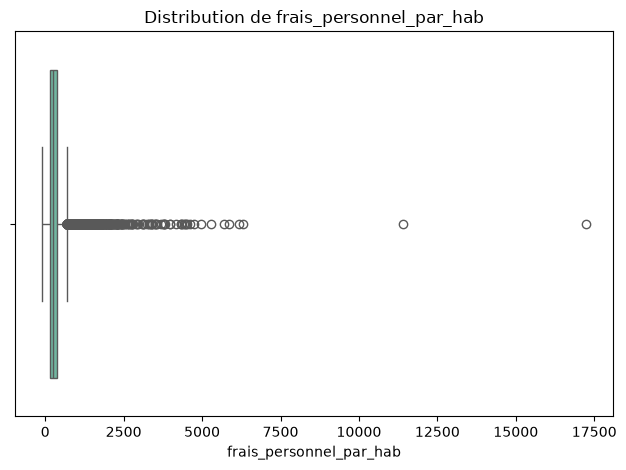

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


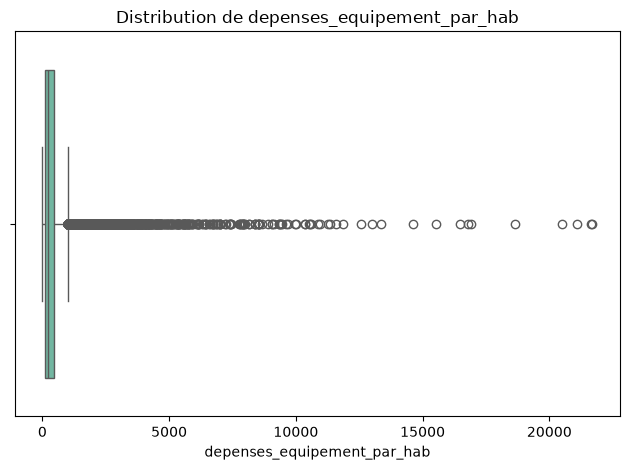

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


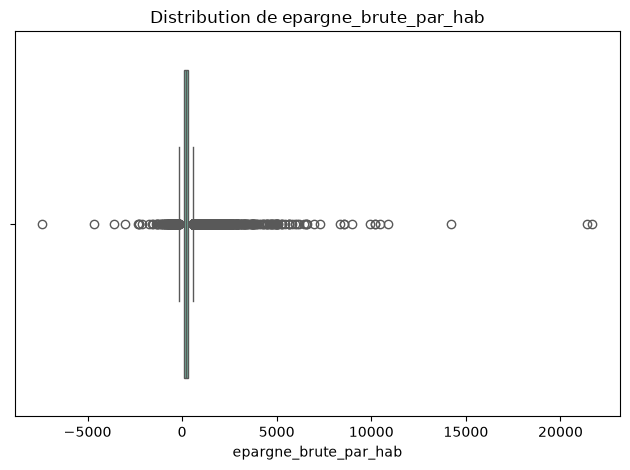

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


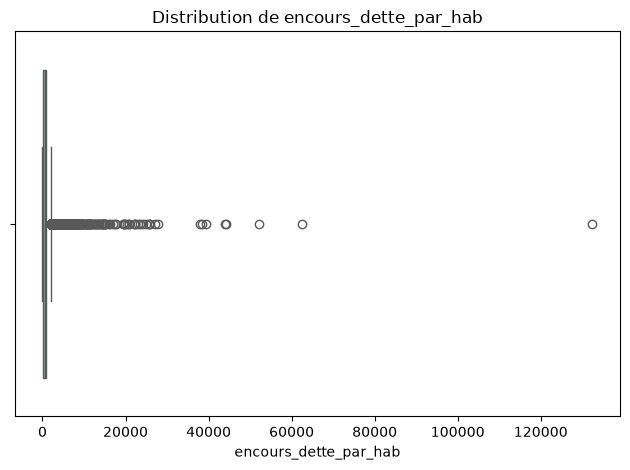

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


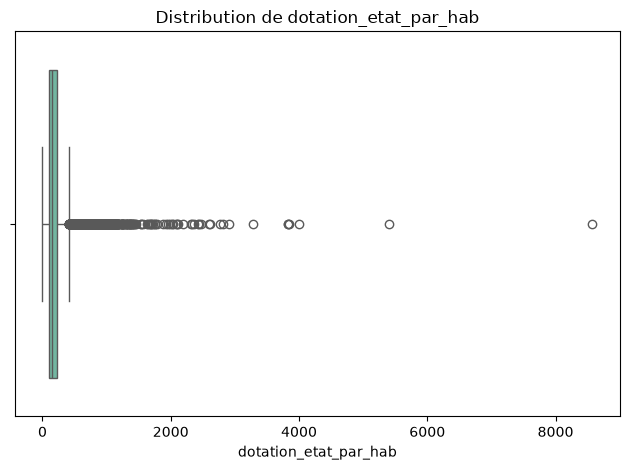

C:\Users\imad\AppData\Local\Temp\ipykernel_6220\505509123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = df[col], palette="Set2")


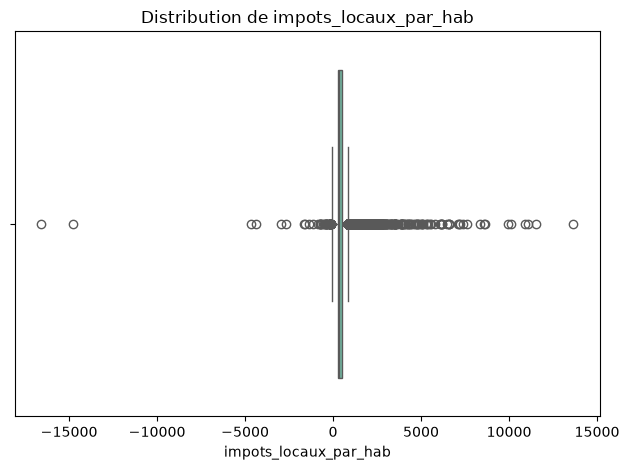

In [17]:
for col in numerical_features:
    sns.boxplot(x = df[col], palette="Set2")
    plt.title(f"Distribution de {col}")
    plt.tight_layout()
    nom_fichier = f"boxplot__{col}.png"
    path_boxplot = FIGURES_DIR / nom_fichier
    
    plt.savefig(path_boxplot, dpi=300, bbox_inches='tight', transparent=False)
    plt.show()

# Analyse Mulitvariée 

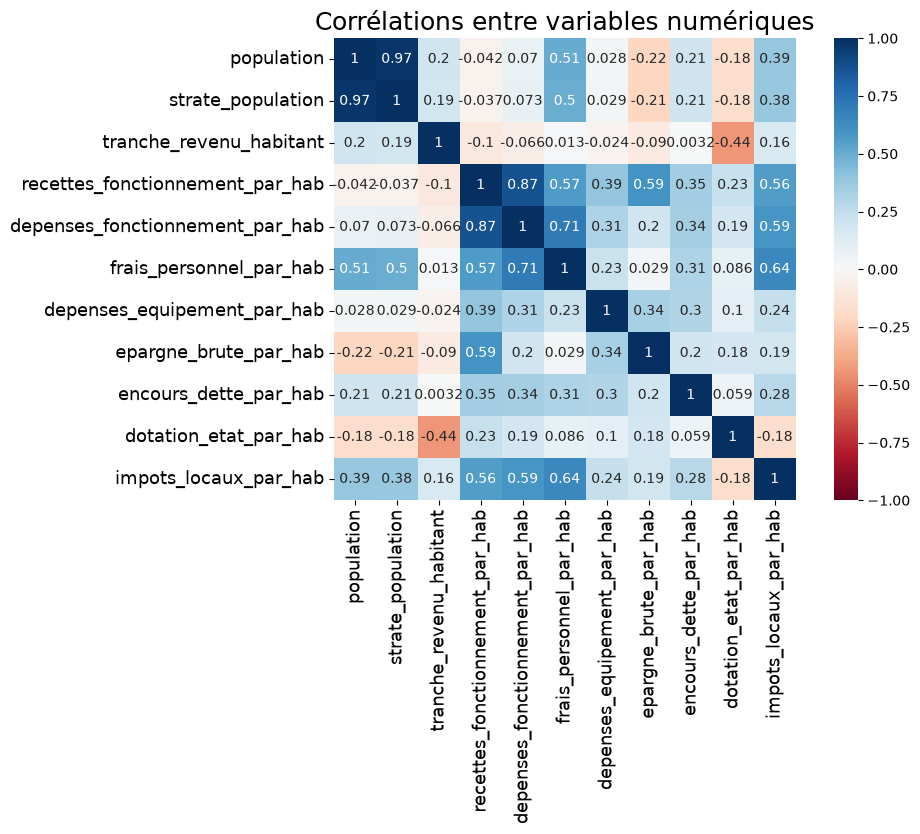

In [18]:
plt.figure(figsize = (10,6))
sns.heatmap(df[numerical_features].corr(method="spearman"),annot=True,square=True,
            cmap='RdBu',
            vmax=1,
            vmin=-1)
plt.title('Corrélations entre variables numériques',size=18)
plt.xticks(size=13)
plt.yticks(size=13)

path_heatmap = FIGURES_DIR / "heatmap_correlations.png"


plt.savefig(path_heatmap, dpi=300, bbox_inches='tight', transparent=False)
plt.show()

# Data Quality Check 

Avant de plonger dans l'analyse, on passe par une étape de Data Quality Check. C'est une bonne pratique qui permet de s'assurer de ne pas traîner des valeurs incohérentes qui pourraient complètement fausser les résultats. 

On va donc filtrer les aberrations logiques ou structurelles comme par exemple : 
* Un code INSEE fait toujours strictement 5 caractères => un code de plus de 5 caractères 
* Une commune ne peut physiquement pas avoir une population négative => une commune avec une population négative 
* Les tranches de revenus doivent impérativement être comprises entre 0 et 5.

L'intérêt de coder ces règles de gestion, c'est la scalabilité. Si l'on doit refaire exactement la même présentation avec le fichier des données de 2023, il suffira d'encapsuler sous une fonction. On pourra ainsi run ce check et nettoyer le nouveau fichier en un instant.

In [19]:
df.loc[df['code_commune'].str.len() != 5, 'code_commune'] = np.nan

df.loc[df['population'] < 0, 'population'] = np.nan

df.loc[(~df['tranche_revenu_habitant'].isin([0,1,2,3,4,5])), 'tranche_revenu_habitant'] = np.nan
df.loc[(~df['strate_population'].isin([0,1,2,3,4,5,6,7,8,9,10])), 'strate_population'] = np.nan


df.loc[~df['commune_rurale'].isin(['Oui', 'Non']), 'commune_rurale'] = np.nan
df.loc[~df['commune_montagne'].isin(['Oui', 'Non']), 'commune_montagne'] = np.nan
df.loc[~df['commune_touristique'].isin(['Oui', 'Non']), 'commune_touristique'] = np.nan

df.loc[df['frais_personnel_par_hab'] > df['depenses_fonctionnement_par_hab'], 'frais_personnel_par_hab'] = np.nan

df.loc[df['region'].str.contains(r'\d', regex=True), 'region'] = np.nan
df.loc[df['departement'].str.contains(r'\d', regex=True), 'departement'] = np.nan
df.loc[df['nom_commune'].str.contains(r'\d', regex=True), 'nom_commune'] = np.nan

# Bouclier Social

Afin d'avvoir une idée concrète de la notion de **fracture fiscale et territoriale** , il est pertinent de cartographier nos données sur une région particulièrement symbolique : l'Île-de-France. 

L'agglomération parisienne est historiquement marquée par une ségrégation spatiale très nette, héritée de la Révolution industrielle :
* **L'Ouest :** Historiquement le lieu de résidence de la bourgeoisie. Au XIXe siècle, les vents dominants (soufflant d'ouest en est) protégeaient ces quartiers des fumées d'usines, attirant ainsi les populations aisées.
* **L'Est et le Nord :** Sous le panache des fumées industrielles, ces territoires sont devenus les terres d'accueil historiques des usines et de la classe ouvrière.

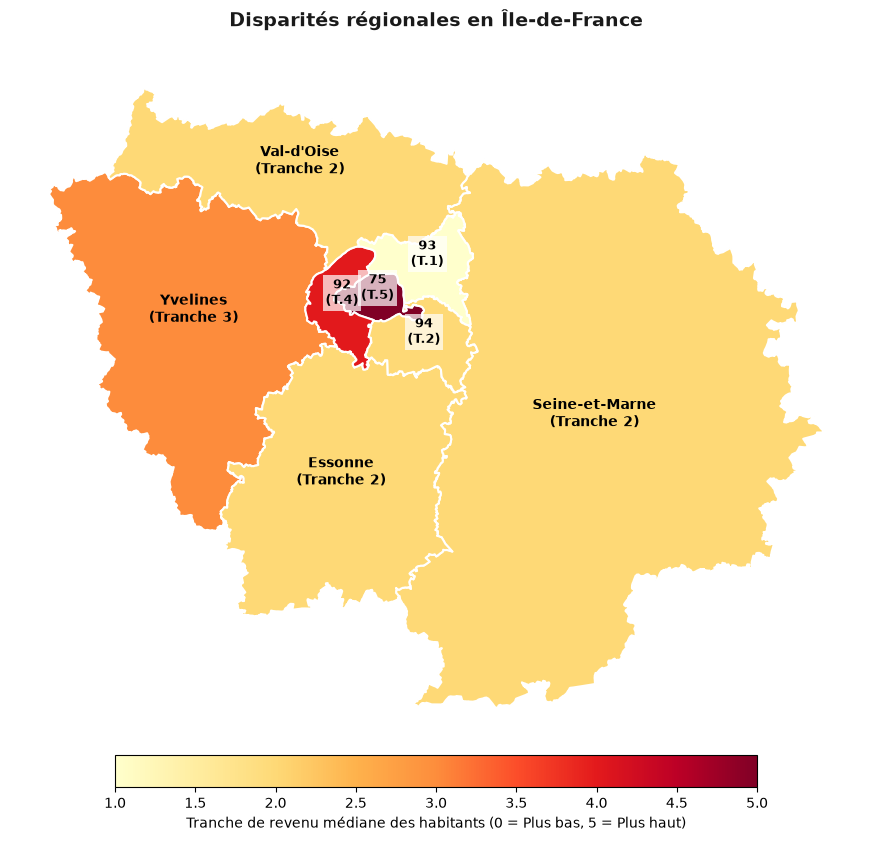

In [20]:
df_idf = df[df['region'] == 'Île-de-France']

df_mediane = df_idf.groupby('departement')['tranche_revenu_habitant'].median().reset_index()

mapping_codes = {
    'Paris': '75',
    'Seine-et-Marne': '77',
    'Yvelines': '78',
    'Essonne': '91',
    'Hauts-de-Seine': '92',
    'Seine-Saint-Denis': '93',
    'Val-de-Marne': '94',
    "Val-d'Oise": '95'
}
df_mediane['code_dept'] = df_mediane['departement'].map(mapping_codes)

url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
gdf_depts = gpd.read_file(url_geojson, engine="fiona")

codes_idf = ['75', '77', '78', '91', '92', '93', '94', '95']
gdf_idf = gdf_depts[gdf_depts['code'].isin(codes_idf)].copy()

gdf_final = gdf_idf.merge(df_mediane, left_on='code', right_on='code_dept')

fig, ax = plt.subplots(figsize=(11, 9))

gdf_final.plot(
    column='tranche_revenu_habitant',
    cmap='YlOrRd', 
    linewidth=1.5,
    ax=ax,
    edgecolor='#ffffff',  
    legend=True,
    legend_kwds={
        'label': "Tranche de revenu médiane des habitants (0 = Plus bas, 5 = Plus haut)",
        'orientation': "horizontal",
        'shrink': 0.6,
        'pad': 0.02
    }
)

for idx, row in gdf_final.iterrows():
    centroid = row['geometry'].centroid
    if row['code'] in ['75', '92', '93', '94']:
        ax.text(centroid.x, centroid.y, f"{row['code']}\n(T.{int(row['tranche_revenu_habitant'])})", 
                fontsize=9, weight='bold', color='black', ha='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
    else:
        ax.text(centroid.x, centroid.y, f"{row['nom']}\n(Tranche {int(row['tranche_revenu_habitant'])})", 
                fontsize=10, weight='bold', color='black', ha='center')

ax.set_title("Disparités régionales en Île-de-France", 
             fontsize=14, pad=20, weight='bold', color='#1a1a1a')
ax.axis('off')  

plt.tight_layout()

path_image = FIGURES_DIR / "carte_ile_de_france.png"

plt.savefig(path_image, dpi=300, bbox_inches='tight', transparent=False)

plt.show()

- ## Répartition des communes françaises 

In [21]:
print(f"Population médiane par commune en France : {df['population'].median():.0f} habitants")

Population médiane par commune en France : 468 habitants


In [22]:
strat_repartition = df.groupby('strate_population')['population'].agg(['min', 'max'])
strat_repartition

,min,max
strate_population,,
0.0,0.0,115.0
1.0,85.0,226.0
2.0,159.0,888.0
3.0,313.0,2163.0
4.0,1806.0,3749.0
5.0,2974.0,5157.0
6.0,3915.0,11967.0
7.0,9220.0,20096.0
8.0,19366.0,50230.0


In [23]:
df.loc[ (df['population'] == 85) & (df['strate_population'] == 1) , 'nom_commune']

32414    Fresnay-le-Samson
Name: nom_commune, dtype: str

In [24]:
df.loc[ (df['population'] == 115) & (df['strate_population'] == 0) , 'nom_commune']

30779        Avezan
30795    Joganville
Name: nom_commune, dtype: str

#### Vérification et compréhension du chevauchement des strates

Lorsqu'on profile les données en calculant les valeurs minimales et maximales de la colonne `population` pour chaque `strate_population`, on observe que **les strates se chevauchent**.

Comme le montre l'analyse des bornes :
* La **Strate 0** contient des communes allant jusqu'à 115 habitants.
* La **Strate 1** contient des communes commençant dès 85 habitants.

Il y a donc une zone de croisement entre 85 et 115 habitants où une commune peut appartenir à l'une ou l'autre des catégories.

**Pourquoi ce phénomène ?**
Il ne s'agit pas d'une erreur de saisie à nettoyer, mais d'une réalité légale. L'administration ne calcule pas la `strate_population` uniquement sur la base de la population stricte (les résidents à l'année). Elle utilise une population "légale" (souvent la population DGF) qui ajoute à la population réelle le poids des **résidences secondaires** ou des capacités d'accueil. 

Ainsi, une commune de 85 habitants permanents mais avec beaucoup de résidences secondaires basculera en Strate 1, tandis qu'une commune de 115 habitants sans résidences secondaires restera en Strate 0.

In [25]:
df['strate_population'].value_counts(normalize = True).reset_index(name = 'pourcentage').sort_values(by = 'strate_population',ascending = True)

,strate_population,pourcentage
3,0.0,0.094040
2,1.0,0.153527
1,2.0,0.270984
0,3.0,0.322054
4,4.0,0.065785
6,5.0,0.028513
5,6.0,0.035125
7,7.0,0.015831
8,8.0,0.010334
9,9.0,0.002605


- ## Comment l'état compense la fracture fiscale ? 

In [26]:
df.groupby('tranche_revenu_habitant')[['dotation_etat_par_hab', 'impots_locaux_par_hab', 'recettes_fonctionnement_par_hab']].median().reset_index()


,tranche_revenu_habitant,dotation_etat_par_hab,impots_locaux_par_hab,recettes_fonctionnement_par_hab
0,0.0,359.620,357.100,1552.47
1,1.0,192.220,339.100,895.31
2,2.0,125.760,365.100,814.43
3,3.0,84.215,455.870,882.99
4,4.0,67.470,497.745,993.25
5,5.0,49.550,595.780,1127.89


In [27]:
df.loc[df['tranche_revenu_habitant'] == 0, 'strate_population'].value_counts(normalize = True)

strate_population
0.0    0.485311
1.0    0.207991
2.0    0.112808
3.0    0.052879
6.0    0.048179
7.0    0.032902
8.0    0.022327
4.0    0.016451
9.0    0.010576
5.0    0.010576
Name: proportion, dtype: float64

On observe que la tranche de revenu zéro est majoritairement composé de macros communes et de petits villages, d'ou l'explosion de la dépense de fonctionnement par habitant 

- ## Métropole vs Outre-mer 
- ### Dom-Tom

On commence par identifier les territoires d'Outer-Mer : 

In [28]:
df['region'].unique()

<StringArray>
[             'Île-de-France', 'Provence-Alpes-Côte d'Azur',
       'Auvergne-Rhône-Alpes',                  'Occitanie',
           'Pays de la Loire',                  'Grand Est',
         'Nouvelle-Aquitaine',            'Hauts-de-France',
                   'Bretagne',                  'Normandie',
    'Bourgogne-Franche-Comté',                 'La Réunion',
        'Centre-Val de Loire',                 'Martinique',
                    'Mayotte',                      'Corse',
                     'Guyane',                 'Guadeloupe']
Length: 18, dtype: str

In [29]:
liste_dom_tom = ['Guadeloupe', 'Martinique', 'Guyane', 'La Réunion', 'Mayotte']
df_domtom = df[df['departement'].isin(liste_dom_tom)]
analyse_domtom = df_domtom.groupby('departement')[['depenses_fonctionnement_par_hab', 'dotation_etat_par_hab', 'impots_locaux_par_hab', 'population']].median().round(0)
print(analyse_domtom.median())
print("Tranche de revenue médiane dans les Dom-Tom : ", df_domtom['tranche_revenu_habitant'].median())

depenses_fonctionnement_par_hab    1423.0
dotation_etat_par_hab               225.0
impots_locaux_par_hab               432.0
population                         7978.0
dtype: float64
Tranche de revenue médiane dans les Dom-Tom :  1.0


- ### Métropole 

In [30]:
df_metropole = df[~df['departement'].isin(liste_dom_tom)]
analyse_metropole = df_metropole.groupby('departement')[['depenses_fonctionnement_par_hab', 'dotation_etat_par_hab', 'impots_locaux_par_hab', 'population']].median().round(2)
print(analyse_metropole.median().round(0))
print("Tranche de revenue médiane en métropole : ", df_metropole['tranche_revenu_habitant'].median())

depenses_fonctionnement_par_hab    689.0
dotation_etat_par_hab              162.0
impots_locaux_par_hab              384.0
population                         478.0
dtype: float64
Tranche de revenue médiane en métropole :  1.0


- ## Profiling : pourquoi dans la tranche de revenu 0 les dépenses de fonctionnement explosent ? 

On compare deux villes qui sont des opposés, Noisy-le-Grand qui est ma ville de résidence ainsi qu'une ville choisie au hasard très peu peuplée. Ensuite, on compare leur dépense par habitant puis la dépense totale globale.

In [31]:
df.loc[df['population'] == 3, 'nom_commune']

34923    Leménil-Mitry
Name: nom_commune, dtype: str

In [32]:
df.loc[df['nom_commune'] == 'Leménil-Mitry']

,code_commune,nom_commune,region,departement,population,strate_population,commune_rurale,commune_montagne,commune_touristique,tranche_revenu_habitant,recettes_fonctionnement_par_hab,depenses_fonctionnement_par_hab,frais_personnel_par_hab,depenses_equipement_par_hab,epargne_brute_par_hab,encours_dette_par_hab,dotation_etat_par_hab,impots_locaux_par_hab
34923,54310,Leménil-Mitry,Grand Est,Meurthe-et-Moselle,3.0,0.0,Oui,Non,Non,0.0,4241.51,6560.5,1480.26,0.0,-2318.99,0.0,2192.33,1809.64


In [33]:
df.loc[df['nom_commune'] == 'Noisy-le-Grand']

,code_commune,nom_commune,region,departement,population,strate_population,commune_rurale,commune_montagne,commune_touristique,tranche_revenu_habitant,recettes_fonctionnement_par_hab,depenses_fonctionnement_par_hab,frais_personnel_par_hab,depenses_equipement_par_hab,epargne_brute_par_hab,encours_dette_par_hab,dotation_etat_par_hab,impots_locaux_par_hab
76,93051,Noisy-le-Grand,Île-de-France,Seine-Saint-Denis,68256.0,9.0,Non,Non,Non,2.0,1845.24,1486.51,959.99,489.41,358.73,1092.97,87.39,1353.89
